In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração básica de visualização
sns.set(style="whitegrid")
%matplotlib inline


In [2]:
# Defina o caminho do arquivo Excel
file_path = 'Dados 3.xlsx'

# Ler todas as planilhas (abas) em um dicionário
sheets = pd.read_excel(file_path, sheet_name=None)
print("Planilhas encontradas:", list(sheets.keys()))

# Converter o dicionário em uma lista de DataFrames (cada um deve ter a coluna "ID_Cliente")
dfs = list(sheets.values())

# Realizar o merge dos DataFrames com base na coluna "ID_Cliente"
# Utilizamos um merge do tipo "outer" para manter todos os registros
df_merged = dfs[0]
for df_temp in dfs[1:]:
    df_merged = pd.merge(df_merged, df_temp, on='ID_Cliente', how='outer')

# Exibir dimensões e as primeiras linhas do DataFrame integrado
print("Dimensões do DataFrame integrado:", df_merged.shape)
df_merged.head()


Planilhas encontradas: ['Base1', 'Base2', 'Base3']
Dimensões do DataFrame integrado: (250, 11)


,ID_Cliente,Idade,Genero,Estado_Civil,Escolaridade,Numero_de_Dependentes,Tipo_de_Residencia,Inadimplencia,Renda_Anual,Valor_do_Emprestimo,Prazo_do_Emprestimo
0,1,35,F,Casado,Ensino Superior,1,Casa Própria,Não,60000.0,10000.0,36.0
1,2,28,F,NaN,Ensino Médio,0,Casa Própria,Não,40000.0,8000.0,24.0
2,3,45,F,Casado,Pós-Graduação,2,Casa Alugada,Não,100.0,15000.0,48.0
3,4,40,F,Divorciado,Ensino Superior,0,Casa Própria,Não,NaN,12000.0,36.0
4,5,33,F,Casado,Ensino Médio,1,Casa Alugada,Sim,50000.0,9000.0,24.0


In [3]:
# Crie um alias 'df' a partir do DataFrame integrado
df = df_merged.copy()

# Exibir informações gerais do DataFrame
print("Info do DataFrame:")
df.info()

# Visualizar as primeiras linhas
print("Primeiras linhas:")
print(df.head())

# Estatísticas descritivas das colunas numéricas
print("Estatísticas descritivas:")
print(df.describe())

# Verificar a quantidade de dados faltantes por coluna
print("Valores faltantes por coluna:")
print(df.isnull().sum())


Info do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Cliente             250 non-null    int64  
 1   Idade                  250 non-null    int64  
 2   Genero                 248 non-null    object 
 3   Estado_Civil           246 non-null    object 
 4   Escolaridade           248 non-null    object 
 5   Numero_de_Dependentes  250 non-null    int64  
 6   Tipo_de_Residencia     249 non-null    object 
 7   Inadimplencia          250 non-null    object 
 8   Renda_Anual            244 non-null    float64
 9   Valor_do_Emprestimo    246 non-null    float64
 10  Prazo_do_Emprestimo    246 non-null    float64
dtypes: float64(3), int64(3), object(5)
memory usage: 21.6+ KB
Primeiras linhas:
   ID_Cliente  Idade Genero Estado_Civil     Escolaridade  \
0           1     35      F       Casado  Ensino Superior 

In [4]:
# Converter valores negativos de 'Renda_Anual' e 'Valor_do_Emprestimo' para positivos
df['Renda_Anual'] = df['Renda_Anual'].abs()
df['Valor_do_Emprestimo'] = df['Valor_do_Emprestimo'].abs()

# Para 'Idade': definir como NaN valores fora do intervalo aceitável (18 a 100 anos)
df.loc[(df['Idade'] < 18) | (df['Idade'] > 100), 'Idade'] = np.nan

# Exibir resumo da coluna 'Idade' após correção
print("Resumo da coluna 'Idade' após tratamento:")
print(df['Idade'].describe())


Resumo da coluna 'Idade' após tratamento:
count    244.000000
mean      41.073770
std        8.111535
min       20.000000
25%       34.000000
50%       41.000000
75%       48.000000
max       58.000000
Name: Idade, dtype: float64


In [5]:
# Ordenar o DataFrame pela coluna 'ID_Cliente' e resetar o índice
df.sort_values(by='ID_Cliente', inplace=True)
df.reset_index(drop=True, inplace=True)

# Exibir as 10 primeiras linhas para confirmar a ordenação
print("Exemplo dos 10 primeiros ID_Cliente:")
print(df[['ID_Cliente']].head(10))


Exemplo dos 10 primeiros ID_Cliente:
   ID_Cliente
0           1
1           2
2           3
3           4
4           5
5           6
6           7
7           8
8           9
9          10


In [6]:
def winsorize_series(s, k=1.5):
    # Calcular os quartis e o IQR
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    # Definir limites inferior e superior
    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR
    # Aplicar winsorização: valores abaixo ou acima dos limites serão substituídos pelos próprios limites
    return s.clip(lower=lower_bound, upper=upper_bound)

# Armazenar os valores originais de 'Renda_Anual' para comparação (já com negativos transformados em positivos)
renda_original = df['Renda_Anual'].copy()

# Aplicar winsorização nas colunas de interesse
df['Renda_Anual'] = winsorize_series(df['Renda_Anual'])
df['Valor_do_Emprestimo'] = winsorize_series(df['Valor_do_Emprestimo'])
# Para 'Idade', você pode optar por não aplicar winsorização ou tratar de forma diferenciada
# df['Idade'] = winsorize_series(df['Idade'])


In [7]:
# transformar em int e manter NaN
df['Idade'] = df['Idade'].astype('float64').astype('Int64')
df['Idade']

0      35
1      28
2      45
3      40
4      33
       ..
245    51
246    46
247    41
248    36
249    31
Name: Idade, Length: 250, dtype: Int64

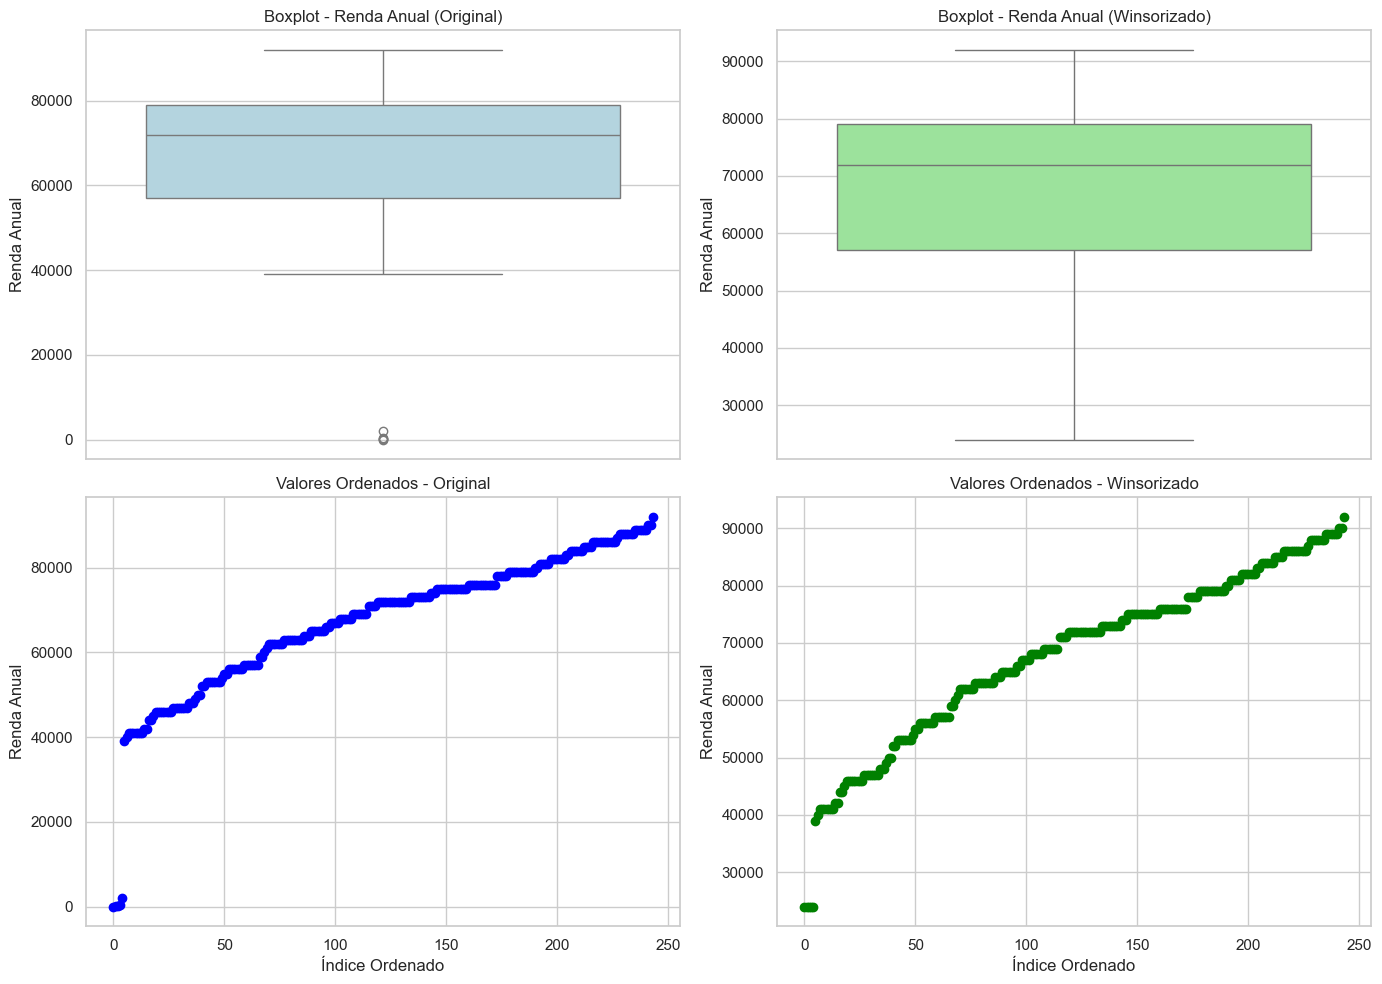

In [8]:
# Utilizando os dados originais de 'Renda_Anual' (armazenados em renda_original)
# e os dados winsorizados (agora em df['Renda_Anual'])

# Criação dos gráficos comparativos para a coluna 'Renda_Anual'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot para os dados originais
sns.boxplot(y=renda_original, ax=axes[0, 0], color='lightblue')
axes[0, 0].set_title('Boxplot - Renda Anual (Original)')
axes[0, 0].set_ylabel('Renda Anual')

# 2. Boxplot para os dados winsorizados
sns.boxplot(y=df['Renda_Anual'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Boxplot - Renda Anual (Winsorizado)')
axes[0, 1].set_ylabel('Renda Anual')

# 3. Gráfico de dispersão (scatter) dos valores ordenados originais
sorted_orig = np.sort(renda_original.dropna())
axes[1, 0].plot(sorted_orig, marker='o', linestyle='None', color='blue')
axes[1, 0].set_title('Valores Ordenados - Original')
axes[1, 0].set_xlabel('Índice Ordenado')
axes[1, 0].set_ylabel('Renda Anual')

# 4. Gráfico de dispersão (scatter) dos valores ordenados winsorizados
sorted_win = np.sort(df['Renda_Anual'].dropna())
axes[1, 1].plot(sorted_win, marker='o', linestyle='None', color='green')
axes[1, 1].set_title('Valores Ordenados - Winsorizado')
axes[1, 1].set_xlabel('Índice Ordenado')
axes[1, 1].set_ylabel('Renda Anual')

plt.tight_layout()
plt.show()


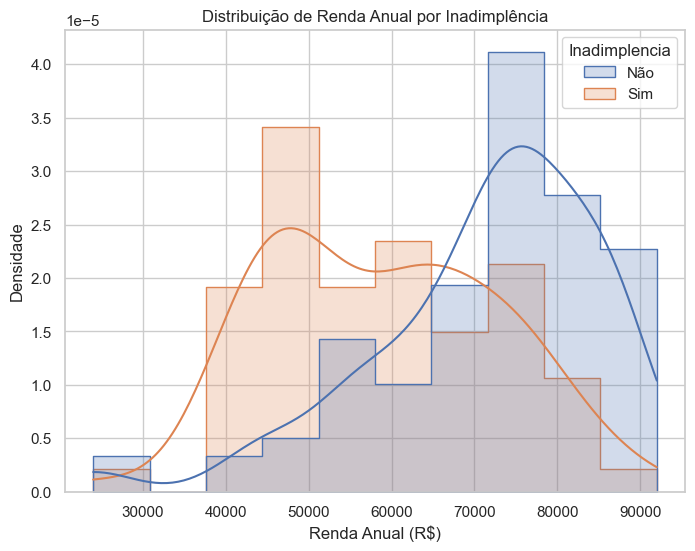

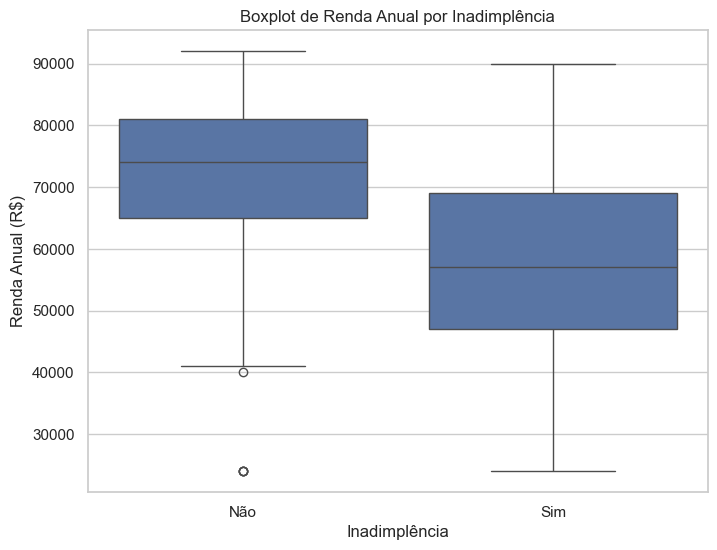

In [14]:
# Gráfico 1: Histograma com densidade (KDE) para Renda_Anual por Inadimplência
plt.figure(figsize=(8,6))
sns.histplot(
    data=df, 
    x='Renda_Anual', 
    hue='Inadimplencia', 
    kde=True, 
    element="step", 
    stat="density", 
    common_norm=False
)
plt.title('Distribuição de Renda Anual por Inadimplência')
plt.xlabel('Renda Anual (R$)')
plt.ylabel('Densidade')
plt.show()

# Gráfico 2: Boxplot para comparar estatísticas de Renda_Anual por Inadimplência
plt.figure(figsize=(8,6))
sns.boxplot(x='Inadimplencia', y='Renda_Anual', data=df)
plt.title('Boxplot de Renda Anual por Inadimplência')
plt.xlabel('Inadimplência')
plt.ylabel('Renda Anual (R$)')
plt.show()


In [9]:
# Transformar 'Idade' para tipo int preservando NaN (usando o tipo Int64 do pandas)
df['Idade'] = df['Idade'].astype('float64').astype('Int64')

# Reordenar as colunas para deixar 'Inadimplencia' como a última coluna
colunas = [col for col in df.columns if col != 'Inadimplencia'] + ['Inadimplencia']
df = df[colunas]


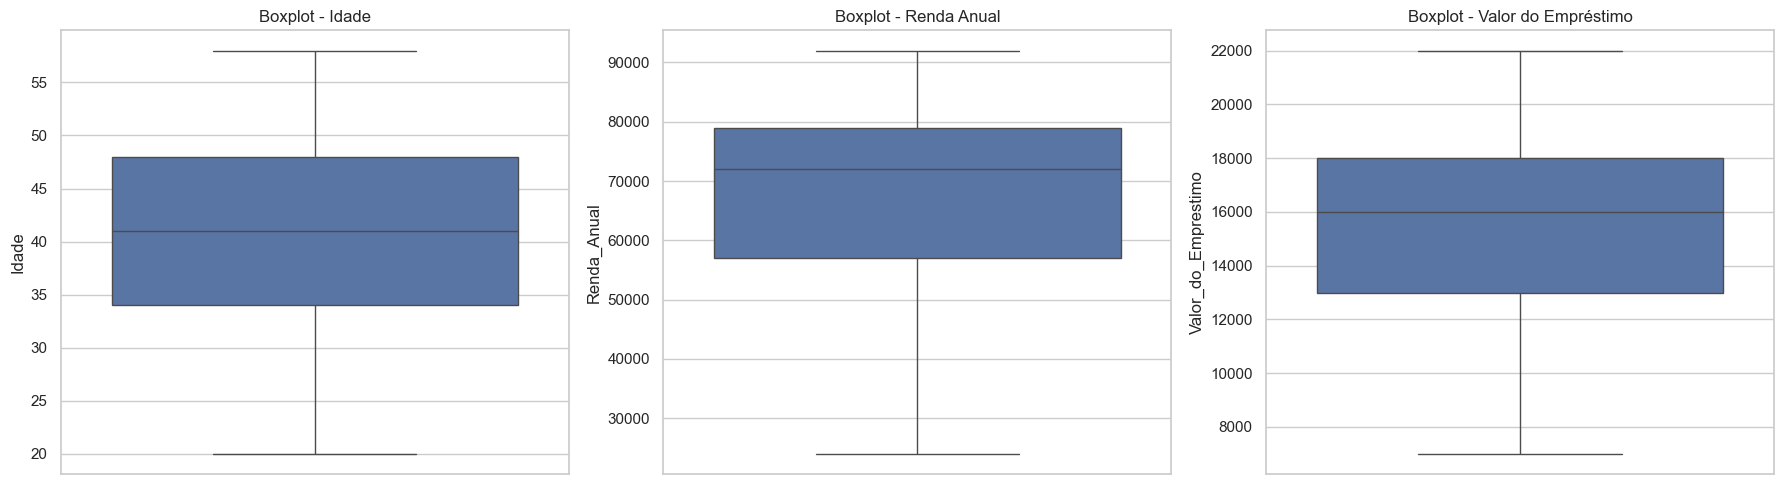

In [10]:
# Gerar boxplots individuais para as colunas principais após o tratamento

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['Idade'], ax=axes[0])
axes[0].set_title('Boxplot - Idade')

sns.boxplot(y=df['Renda_Anual'], ax=axes[1])
axes[1].set_title('Boxplot - Renda Anual')

sns.boxplot(y=df['Valor_do_Emprestimo'], ax=axes[2])
axes[2].set_title('Boxplot - Valor do Empréstimo')

plt.tight_layout()
plt.show()


In [11]:
# Salvar o DataFrame final limpo em um arquivo CSV
df.to_csv('dados_limpos.csv', index=False)
print("DataFrame limpo salvo em 'dados_limpos.csv'")


DataFrame limpo salvo em 'dados_limpos.csv'
